# Enhanced Credit Card Fraud Detection

## 1. Library Imports and Setup

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')


Train shape: (1296675, 23)
Test shape: (555719, 23)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat   

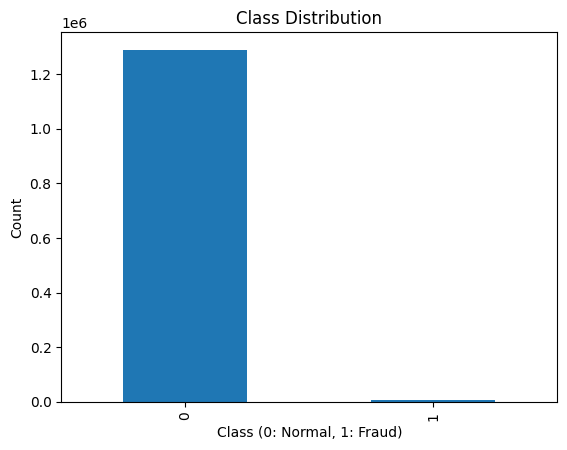

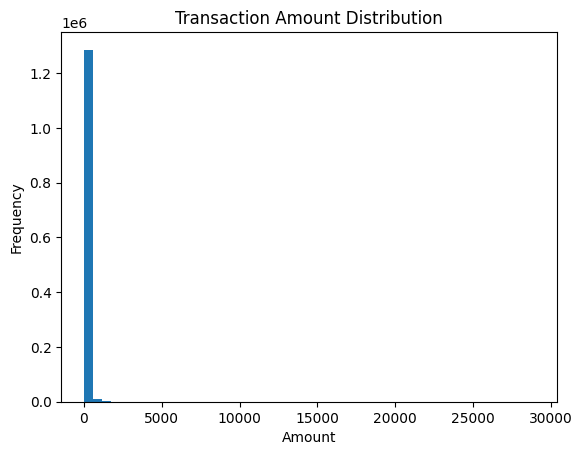

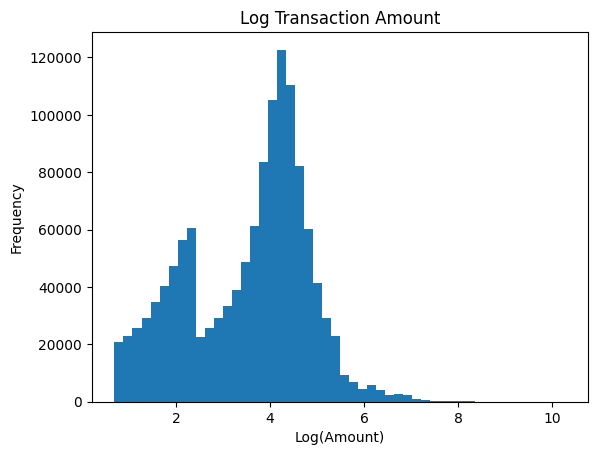

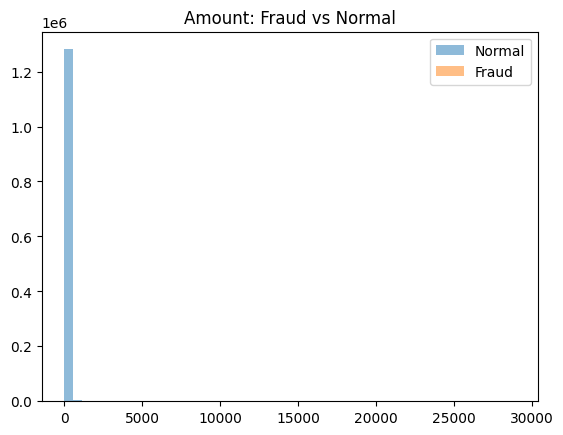

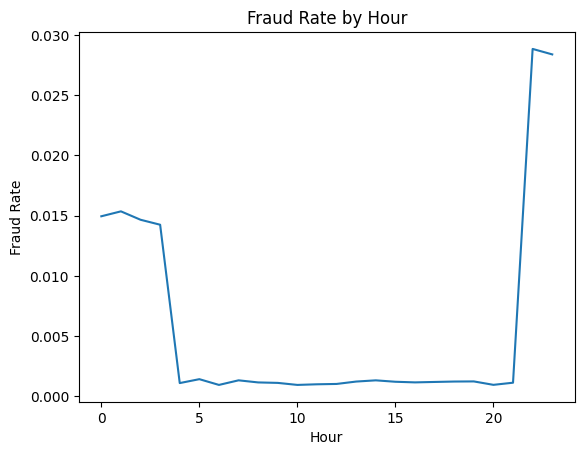

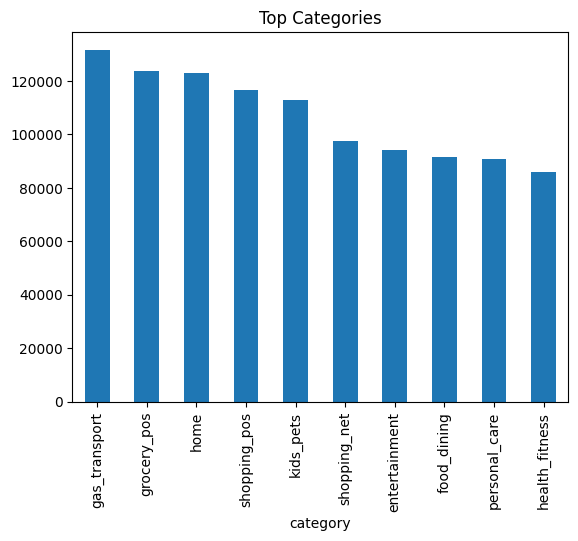

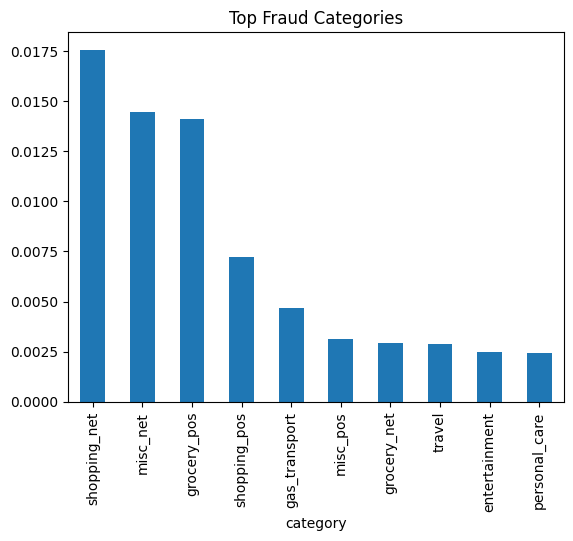

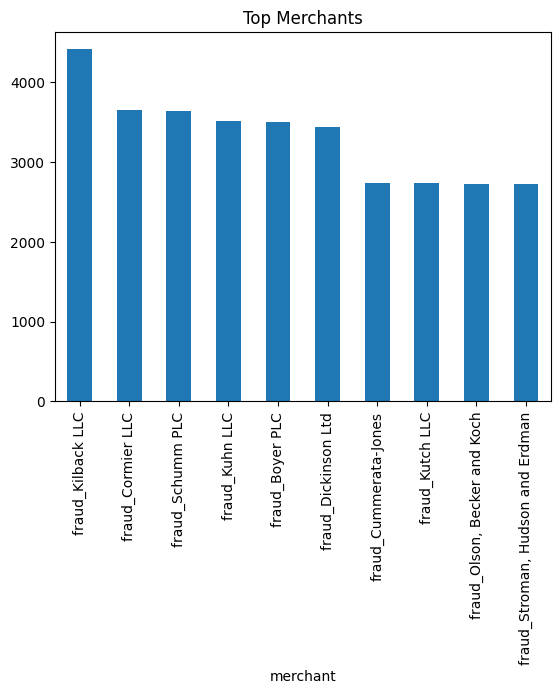

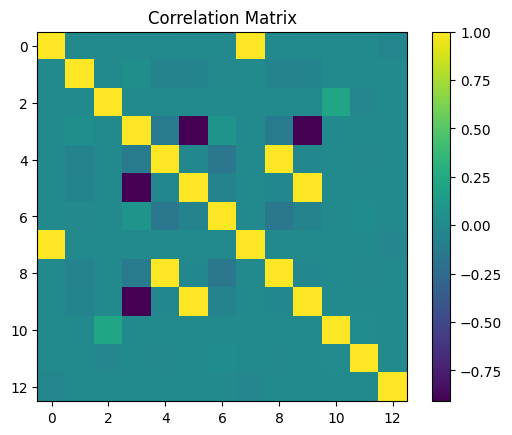


Avg transactions per user: 1319.0996948118006
Avg amount per user: 110.99466553798833

Fraud sample:
      Unnamed: 0 trans_date_trans_time           cc_num  \
2449        2449   2019-01-02 01:06:37    4613314721966   
2472        2472   2019-01-02 01:47:29  340187018810220   
2523        2523   2019-01-02 03:05:23  340187018810220   
2546        2546   2019-01-02 03:38:03    4613314721966   
2553        2553   2019-01-02 03:55:47  340187018810220   

                              merchant       category     amt  first    last  \
2449            fraud_Rutherford-Mertz    grocery_pos  281.06  Jason  Murphy   
2472  fraud_Jenkins, Hauck and Friesen  gas_transport   11.52  Misty    Hart   
2523            fraud_Goodwin-Nitzsche    grocery_pos  276.31  Misty    Hart   
2546            fraud_Erdman-Kertzmann  gas_transport    7.03  Jason  Murphy   
2553                fraud_Koepp-Parker    grocery_pos  275.73  Misty    Hart   

     gender                     street  ... city_pop  \
2449  

In [1]:

# ===================== IMPORT =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== LOAD DATA =====================
train_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv'
test_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# ===================== BASIC INFO =====================
print("\n=== INFO ===")
print(train.info())

print("\n=== DESCRIBE ===")
print(train.describe())

# ===================== CHECK MISSING =====================
print("\n=== MISSING VALUES ===")
print(train.isnull().sum())

# ===================== CLASS DISTRIBUTION =====================
print("\n=== CLASS DISTRIBUTION ===")
print(train['is_fraud'].value_counts())
print(train['is_fraud'].value_counts(normalize=True))

# Plot class imbalance
plt.figure()
train['is_fraud'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.show()

# ===================== TRANSACTION AMOUNT =====================
plt.figure()
plt.hist(train['amt'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Log scale (quan trọng)
plt.figure()
plt.hist(np.log1p(train['amt']), bins=50)
plt.title("Log Transaction Amount")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

# ===================== FRAUD VS NORMAL AMOUNT =====================
plt.figure()
plt.hist(train[train['is_fraud']==0]['amt'], bins=50, alpha=0.5)
plt.hist(train[train['is_fraud']==1]['amt'], bins=50, alpha=0.5)
plt.title("Amount: Fraud vs Normal")
plt.legend(["Normal", "Fraud"])
plt.show()

# ===================== TIME FEATURE =====================
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])

train['hour'] = train['trans_date_trans_time'].dt.hour
train['day'] = train['trans_date_trans_time'].dt.dayofweek

# Hour distribution
plt.figure()
train.groupby('hour')['is_fraud'].mean().plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

# ===================== CATEGORY ANALYSIS =====================
top_categories = train['category'].value_counts().head(10)

plt.figure()
top_categories.plot(kind='bar')
plt.title("Top Categories")
plt.show()

# Fraud rate by category
fraud_by_cat = train.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(10)

plt.figure()
fraud_by_cat.plot(kind='bar')
plt.title("Top Fraud Categories")
plt.show()

# ===================== MERCHANT ANALYSIS =====================
top_merchants = train['merchant'].value_counts().head(10)

plt.figure()
top_merchants.plot(kind='bar')
plt.title("Top Merchants")
plt.show()

# ===================== CORRELATION =====================
numeric_cols = train.select_dtypes(include=[np.number]).columns

corr = train[numeric_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

# ===================== FEATURE ENGINEERING (EDA) =====================
# Transaction per user

txn_per_user = train.groupby('cc_num')['amt'].count()

print("\nAvg transactions per user:", txn_per_user.mean())

# Avg amount per user
avg_amt_user = train.groupby('cc_num')['amt'].mean()

print("Avg amount per user:", avg_amt_user.mean())

# ===================== FRAUD PATTERN =====================
fraud = train[train['is_fraud'] == 1]

print("\nFraud sample:")
print(fraud.head())

print("\nFraud amount stats:")
print(fraud['amt'].describe())


## 2. Feature Engineering nang cao

Them 3 nhom feature moi:

- **Velocity**: `tx_count_1h`, `amt_sum_1h` -- so GD va tong tien trong 1h gan nhat cua the
- **Amount deviation**: `amt_zscore`, `amt_ratio` -- muc do lech cua GD so voi thoi quen the
- **Distance deviation**: `dist_from_prev`, `log_dist_from_prev` -- khoang cach den merchant GD lien truoc

> Tat ca tinh **leak-free**: velocity dung sliding window chi nhin qua khu, deviation dung stats tu train map sang test, distance dung `shift(1)` theo cc_num.

In [2]:

# ===================== IMPORT =====================
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# ===================== LOAD DATA =====================
train_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv'
test_path  = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv'

train = pd.read_csv(train_path, parse_dates=['trans_date_trans_time', 'dob'])
test  = pd.read_csv(test_path,  parse_dates=['trans_date_trans_time', 'dob'])

# Sort theo thoi gian - bat buoc cho velocity features
train = train.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
test  = test.sort_values(['cc_num',  'trans_date_trans_time']).reset_index(drop=True)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


# ─────────────────────────────────────────────────────
# BASE FEATURES (khong leak)
# ─────────────────────────────────────────────────────
def base_features(df):
    df = df.copy()
    df['trans_hour']    = df['trans_date_trans_time'].dt.hour
    df['trans_month']   = df['trans_date_trans_time'].dt.month
    df['trans_weekday'] = df['trans_date_trans_time'].dt.weekday
    df['is_weekend']    = df['trans_weekday'].isin([5, 6]).astype(int)
    df['is_night']      = df['trans_hour'].isin([22,23,0,1,2,3,4,5]).astype(int)
    df['hour_sin']      = np.sin(2 * np.pi * df['trans_hour'] / 24)
    df['hour_cos']      = np.cos(2 * np.pi * df['trans_hour'] / 24)
    df['age']           = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
    df['distance_km']   = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    df['log_distance']  = np.log1p(df['distance_km'])
    df['log_amt']       = np.log1p(df['amt'])
    return df


# ─────────────────────────────────────────────────────
# NEW FEATURE 1: VELOCITY (sliding window 1 gio)
# Y nghia: ke gian thuong thuc hien nhieu GD lien tiep trong thoi gian ngan
# Leak-free: voi moi GD, chi dem GD TRUOC DO trong 1 gio (khong tinh chinh no)
# ─────────────────────────────────────────────────────
def add_velocity_features(df):
    df = df.copy()
    df['unix_ts'] = df['trans_date_trans_time'].astype(np.int64) // 10**9

    count_1h_arr = np.zeros(len(df), dtype=int)
    sum_1h_arr   = np.zeros(len(df), dtype=float)

    for cc, grp in df.groupby('cc_num', sort=False):
        idx  = grp.index.tolist()
        ts   = grp['unix_ts'].values
        amt  = grp['amt'].values
        left = 0
        for right in range(len(idx)):
            while ts[right] - ts[left] > 3600:
                left += 1
            count_1h_arr[idx[right]] = right - left          # GD truoc trong 1h
            sum_1h_arr[idx[right]]   = amt[left:right].sum() # tong tien truoc trong 1h

    df['tx_count_1h'] = count_1h_arr
    df['amt_sum_1h']  = sum_1h_arr
    df.drop(columns=['unix_ts'], inplace=True)
    return df


# ─────────────────────────────────────────────────────
# NEW FEATURE 2: AMOUNT DEVIATION (lech so voi thoi quen the)
# Y nghia: GD bat thuong thuong co so tien rat khac trung binh lich su
# Leak-free: user_stats tinh tu TRAIN, map sang test
# ─────────────────────────────────────────────────────
def add_amount_deviation(df, user_stats=None, fit=True):
    df = df.copy()
    if fit:
        user_stats = (df.groupby('cc_num')['amt']
                      .agg(['mean','count','std'])
                      .rename(columns={'mean':'avg_amt_user',
                                       'count':'tx_count_user',
                                       'std':'std_amt_user'})
                      .reset_index())

    df = df.merge(user_stats, on='cc_num', how='left')
    global_mean = df['avg_amt_user'].median()
    df['avg_amt_user'].fillna(global_mean, inplace=True)
    df['tx_count_user'].fillna(1, inplace=True)
    df['std_amt_user'].fillna(df['std_amt_user'].median(), inplace=True)

    # z-score: (amt - mean) / std
    df['amt_zscore'] = (df['amt'] - df['avg_amt_user']) / (df['std_amt_user'] + 1e-6)
    # Ratio: truc quan hon, de giai thich (1.0 = binh thuong, 5.0 = gap 5 lan binh thuong)
    df['amt_ratio']  = df['amt'] / (df['avg_amt_user'] + 1e-6)

    return df, user_stats


# ─────────────────────────────────────────────────────
# NEW FEATURE 3: DISTANCE FROM PREVIOUS TRANSACTION
# Y nghia: fraud thuong xay ra o dia diem rat xa GD hop le truoc do
# (vi du: mua o HN luc 8h, bi fraud o My luc 8h05)
# Leak-free: chi nhin GD lien truoc qua shift(1) trong nhom cc_num
# ─────────────────────────────────────────────────────
def add_distance_deviation(df):
    df = df.copy()
    prev = df.groupby('cc_num')[['merch_lat', 'merch_long']].shift(1)
    df['prev_merch_lat']  = prev['merch_lat']
    df['prev_merch_long'] = prev['merch_long']

    mask = df['prev_merch_lat'].notna()
    df['dist_from_prev'] = 0.0
    df.loc[mask, 'dist_from_prev'] = haversine(
        df.loc[mask, 'merch_lat'],  df.loc[mask, 'merch_long'],
        df.loc[mask, 'prev_merch_lat'], df.loc[mask, 'prev_merch_long']
    )
    df['log_dist_from_prev'] = np.log1p(df['dist_from_prev'])

    median_dist = df.loc[mask, 'dist_from_prev'].median()
    df['dist_from_prev'].fillna(median_dist, inplace=True)
    df['log_dist_from_prev'].fillna(np.log1p(median_dist), inplace=True)
    df.drop(columns=['prev_merch_lat', 'prev_merch_long'], inplace=True)
    return df


# ─────────────────────────────────────────────────────
# AP DUNG PIPELINE
# ─────────────────────────────────────────────────────
print("Buoc 1/6: Base features...")
train_df = base_features(train)
test_df  = base_features(test)

print("Buoc 2/6: Velocity features (sliding window 1h)...")
train_df = add_velocity_features(train_df)
test_df  = add_velocity_features(test_df)

print("Buoc 3/6: Amount deviation features...")
train_df, user_stats   = add_amount_deviation(train_df, fit=True)
test_df,  _            = add_amount_deviation(test_df, user_stats=user_stats, fit=False)

print("Buoc 4/6: Distance deviation features...")
train_df = add_distance_deviation(train_df)
test_df  = add_distance_deviation(test_df)

print("Buoc 5/6: Encoding + Split + SMOTE + Scaling...")
cat_cols = ['merchant', 'category', 'gender', 'city', 'job', 'state']
encoder  = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_df[cat_cols] = encoder.fit_transform(train_df[cat_cols])
test_df[cat_cols]  = encoder.transform(test_df[cat_cols])

drop_cols = ['trans_date_trans_time', 'dob', 'first', 'last',
             'street', 'trans_num', 'unix_time', 'cc_num', 'Unnamed: 0']
train_df.drop(columns=[c for c in drop_cols if c in train_df.columns], inplace=True)
test_df.drop(columns=[c for c in drop_cols if c in test_df.columns], inplace=True)

TARGET = 'is_fraud'
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]
feature_names = list(X_train.columns)

smote = SMOTE(sampling_strategy=0.2, k_neighbors=5, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

scaler      = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test_sc   = scaler.transform(X_test)

NEW_FEATURES = ['tx_count_1h', 'amt_sum_1h', 'amt_zscore', 'amt_ratio',
                'dist_from_prev', 'log_dist_from_prev']

print(f"\n[OK] Feature set moi ({len(feature_names)} features):")
for f in feature_names:
    tag = " <- NEW" if f in NEW_FEATURES else ""
    print(f"   {f}{tag}")
print(f"\nTrain: {X_train_bal.shape} | Test: {X_test_sc.shape}")


Train shape: (1296675, 23)
Test shape: (555719, 23)
Buoc 1/6: Base features...
Buoc 2/6: Velocity features (sliding window 1h)...
Buoc 3/6: Amount deviation features...


/tmp/ipykernel_57/2803949534.py:95: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_amt_user'].fillna(global_mean, inplace=True)
/tmp/ipykernel_57/2803949534.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Buoc 4/6: Distance deviation features...


/tmp/ipykernel_57/2803949534.py:128: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dist_from_prev'].fillna(median_dist, inplace=True)
/tmp/ipykernel_57/2803949534.py:129: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Buoc 5/6: Encoding + Split + SMOTE + Scaling...

[OK] Feature set moi (33 features):
   merchant
   category
   amt
   gender
   city
   state
   zip
   lat
   long
   city_pop
   job
   merch_lat
   merch_long
   trans_hour
   trans_month
   trans_weekday
   is_weekend
   is_night
   hour_sin
   hour_cos
   age
   distance_km
   log_distance
   log_amt
   tx_count_1h <- NEW
   amt_sum_1h <- NEW
   avg_amt_user
   tx_count_user
   std_amt_user
   amt_zscore <- NEW
   amt_ratio <- NEW
   dist_from_prev <- NEW
   log_dist_from_prev <- NEW

Train: (1547002, 33) | Test: (555719, 33)


In [3]:
# ─────────────────────────────────────────────────────────────────
# TRAIN 10 LẦN ĐÚNG CÁCH — KHÔNG DATA LEAKAGE
# Scaler + SMOTE fit lại mỗi lần với seed khác nhau
# ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgblib
import warnings
warnings.filterwarnings('ignore')

# ── Dùng lại X_train, y_train, X_test, y_test từ pipeline của bạn
# (trước bước SMOTE + Scaler — tức là X_train còn là DataFrame gốc)
# ─────────────────────────────────────────────────────────────────

N_RUNS    = 10
THRESHOLD = 0.3

results = {'XGBoost': [], 'Stacking': []}

print(f"Bắt đầu train {N_RUNS} lần...\n")

for run in range(N_RUNS):
    seed = 42 + run
    print(f"{'='*55}")
    print(f"RUN {run+1}/{N_RUNS}  (seed={seed})")
    print(f"{'='*55}")

    # ── SMOTE + Scaler fit lại mỗi lần với seed mới ───────────────
    smote = SMOTE(sampling_strategy=0.2, k_neighbors=5, random_state=seed)
    X_bal, y_bal = smote.fit_resample(X_train, y_train)

    scaler   = StandardScaler()
    X_bal_sc = scaler.fit_transform(X_bal)
    X_te_sc  = scaler.transform(X_test)      # transform bằng scaler của run này

    print(f"  SMOTE xong: {X_bal_sc.shape[0]:,} mẫu train")

    # ════════════════════════════════════════════
    # RANDOM FOREST
    # ════════════════════════════════════════════
    # rf = RandomForestClassifier(
    #     n_estimators=300, max_depth=15, min_samples_leaf=10,
    #     max_features="sqrt", class_weight="balanced",
    #     n_jobs=-1, random_state=seed,
    # )
    # rf.fit(X_bal_sc, y_bal)
    # y_proba_rf = rf.predict_proba(X_te_sc)[:, 1]
    # y_pred_rf  = (y_proba_rf >= THRESHOLD).astype(int)

    # results['Random Forest'].append({
    #     'Accuracy':  accuracy_score(y_test, y_pred_rf),
    #     'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    #     'Recall':    recall_score(y_test, y_pred_rf),
    #     'F1':        f1_score(y_test, y_pred_rf),
    #     'ROC_AUC':   roc_auc_score(y_test, y_proba_rf),
    #     'PR_AUC':    average_precision_score(y_test, y_proba_rf),
    # })
    # print(f"  RF     → F1={results['Random Forest'][-1]['F1']:.4f}  "
    #       f"PR-AUC={results['Random Forest'][-1]['PR_AUC']:.4f}")

    # ════════════════════════════════════════════
    # XGBOOST
    # ════════════════════════════════════════════
    xgb = XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, eval_metric='logloss', random_state=seed,
    )
    xgb.fit(X_bal_sc, y_bal)
    y_proba_xgb = xgb.predict_proba(X_te_sc)[:, 1]
    y_pred_xgb  = (y_proba_xgb >= THRESHOLD).astype(int)

    results['XGBoost'].append({
        'Accuracy':  accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_xgb),
        'F1':        f1_score(y_test, y_pred_xgb),
        'ROC_AUC':   roc_auc_score(y_test, y_proba_xgb),
        'PR_AUC':    average_precision_score(y_test, y_proba_xgb),
    })
    print(f"  XGB    → F1={results['XGBoost'][-1]['F1']:.4f}  "
          f"PR-AUC={results['XGBoost'][-1]['PR_AUC']:.4f}")

    # ════════════════════════════════════════════
    # STACKING
    # ════════════════════════════════════════════
    inner_skf  = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    meta_train = np.zeros((X_bal_sc.shape[0], 2))
    meta_test  = np.zeros((X_te_sc.shape[0], 2))

    xgb_params = dict(n_estimators=300, max_depth=8, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.7,
                      eval_metric='auc', n_jobs=-1, random_state=seed)
    lgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=8,
                      num_leaves=63, subsample=0.8, colsample_bytree=0.7,
                      n_jobs=-1, verbose=-1, random_state=seed)

    for i_tr, i_val in inner_skf.split(X_bal_sc, y_bal):
        Xi_tr, Xi_val = X_bal_sc[i_tr], X_bal_sc[i_val]
        yi_tr, yi_val = y_bal[i_tr],    y_bal[i_val]

        xgb_f = XGBClassifier(**xgb_params)
        lgb_f = LGBMClassifier(**lgb_params)

        xgb_f.fit(Xi_tr, yi_tr, eval_set=[(Xi_val, yi_val)], verbose=False)
        lgb_f.fit(Xi_tr, yi_tr, eval_set=[(Xi_val, yi_val)],
                  callbacks=[lgblib.early_stopping(50, verbose=False),
                              lgblib.log_evaluation(0)])

        meta_train[i_val, 0] = xgb_f.predict_proba(Xi_val)[:, 1]
        meta_train[i_val, 1] = lgb_f.predict_proba(Xi_val)[:, 1]
        meta_test[:, 0]     += xgb_f.predict_proba(X_te_sc)[:, 1] / 3
        meta_test[:, 1]     += lgb_f.predict_proba(X_te_sc)[:, 1] / 3

    meta_model   = LogisticRegression(C=1.0, max_iter=500, random_state=seed)
    meta_model.fit(meta_train, y_bal)
    final_proba  = meta_model.predict_proba(meta_test)[:, 1]
    y_pred_stack = (final_proba >= THRESHOLD).astype(int)

    results['Stacking'].append({
        'Accuracy':  accuracy_score(y_test, y_pred_stack),
        'Precision': precision_score(y_test, y_pred_stack, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_stack),
        'F1':        f1_score(y_test, y_pred_stack),
        'ROC_AUC':   roc_auc_score(y_test, final_proba),
        'PR_AUC':    average_precision_score(y_test, final_proba),
    })
    print(f"  Stack  → F1={results['Stacking'][-1]['F1']:.4f}  "
          f"PR-AUC={results['Stacking'][-1]['PR_AUC']:.4f}")


# ─────────────────────────────────────────────────────────────────
# TỔNG HỢP KẾT QUẢ
# ─────────────────────────────────────────────────────────────────
# METRICS = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Accuracy']

# print("\n\n" + "="*60)
# print(f"  KẾT QUẢ TRUNG BÌNH — {N_RUNS} LẦN CHẠY")
# print("="*60)

# summary = {}
# for model_name, runs in results.items():
#     df_runs = pd.DataFrame(runs)
#     summary[model_name] = {'mean': df_runs.mean(), 'std': df_runs.std()}

#     # Chỉ in XGBoost và Stacking
#     if model_name in ['XGBoost', 'Stacking']:
#         print(f"\n{model_name}:")
#         for m in METRICS:
#             print(f"  {m:<12}: {df_runs[m].mean():.4f} ± {df_runs[m].std():.4f}")


# ─────────────────────────────────────────────────────────────────
# BIỂU ĐỒ MEAN ± STD
# ─────────────────────────────────────────────────────────────────
# import matplotlib.pyplot as plt
# model_names  = ['Random Forest', 'XGBoost', 'Stacking']
# colors       = ['#2196F3', '#FF5722', '#4CAF50']
# plot_metrics = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
# fig, axes = plt.subplots(1, len(plot_metrics), figsize=(18, 5))
# fig.suptitle(f'Kết Quả Trung Bình ± Std ({N_RUNS} lần chạy)',
#              fontsize=13, fontweight='bold')
# for ax, metric in zip(axes, plot_metrics):
#     means = [summary[m]['mean'][metric] for m in model_names]
#     stds  = [summary[m]['std'][metric]  for m in model_names]

#     bars = ax.bar(model_names, means, yerr=stds, capsize=7,
#                   color=colors, alpha=0.82, edgecolor='white',
#                   error_kw={'elinewidth': 2.5, 'ecolor': 'black'})
#     for bar, mean, std in zip(bars, means, stds):
#         ax.text(bar.get_x() + bar.get_width()/2,
#                 bar.get_height() + std + 0.005,
#                 f'{mean:.3f}', ha='center', va='bottom',
#                 fontsize=9, fontweight='bold')

#     ax.set_ylim(0, min(1.15, max(means) + max(stds) + 0.1))
#     ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
#     ax.set_title(metric.replace('_', '-'), fontsize=11, fontweight='bold')
#     ax.grid(axis='y', alpha=0.3, linestyle='--')
#     ax.spines[['top', 'right']].set_visible(False)

# plt.tight_layout()
# plt.savefig('fig_mean_std_10runs.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\n✅ Hoàn thành! Lưu kết quả lần cuối để vẽ biểu đồ chi tiết:")
# print("  y_proba_rf, y_pred_rf, y_proba_xgb, y_pred_xgb, final_proba, y_pred_stack")

Bắt đầu train 10 lần...

RUN 1/10  (seed=42)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8276  PR-AUC=0.8877
  Stack  → F1=0.8517  PR-AUC=0.8969
RUN 2/10  (seed=43)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8246  PR-AUC=0.8875
  Stack  → F1=0.8522  PR-AUC=0.8959
RUN 3/10  (seed=44)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8290  PR-AUC=0.8857
  Stack  → F1=0.8544  PR-AUC=0.8976
RUN 4/10  (seed=45)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8296  PR-AUC=0.8862
  Stack  → F1=0.8518  PR-AUC=0.8964
RUN 5/10  (seed=46)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8345  PR-AUC=0.8865
  Stack  → F1=0.8535  PR-AUC=0.8966
RUN 6/10  (seed=47)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8308  PR-AUC=0.8900
  Stack  → F1=0.8532  PR-AUC=0.8971
RUN 7/10  (seed=48)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8260  PR-AUC=0.8869
  Stack  → F1=0.8501  PR-AUC=0.8946
RUN 8/10  (seed=49)
  SMOTE xong: 1,547,002 mẫu train
  XGB    → F1=0.8325  PR-AUC=0.8868
  S

In [4]:

METRICS = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Accuracy']

print("\n\n" + "="*60)
print(f"  KẾT QUẢ TRUNG BÌNH — {N_RUNS} LẦN CHẠY")
print("="*60)

summary = {}
for model_name, runs in results.items():
    df_runs = pd.DataFrame(runs)
    summary[model_name] = {'mean': df_runs.mean(), 'std': df_runs.std()}
    print(f"\n{model_name}:")
    for m in METRICS:
        print(f"  {m:<12}: {df_runs[m].mean():.4f} ± {df_runs[m].std():.4f}")



  KẾT QUẢ TRUNG BÌNH — 10 LẦN CHẠY

XGBoost:
  F1          : 0.8293 ± 0.0029
  Precision   : 0.8285 ± 0.0055
  Recall      : 0.8301 ± 0.0023
  PR_AUC      : 0.8870 ± 0.0012
  ROC_AUC     : 0.9961 ± 0.0001
  Accuracy    : 0.9987 ± 0.0000

Stacking:
  F1          : 0.8524 ± 0.0013
  Precision   : 0.9033 ± 0.0026
  Recall      : 0.8069 ± 0.0018
  PR_AUC      : 0.8963 ± 0.0009
  ROC_AUC     : 0.9965 ± 0.0001
  Accuracy    : 0.9989 ± 0.0000


In [8]:
METRICS = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Accuracy']

print("\n\n" + "="*60)
print(f"  KẾT QUẢ TRUNG BÌNH — {N_RUNS} LẦN CHẠY")
print("="*60)

summary = {}
for model_name, runs in results.items():
    df_runs = pd.DataFrame(runs)
    summary[model_name] = {'mean': df_runs.mean(), 'std': df_runs.std()}

    # Chỉ in XGBoost và Stacking
    if model_name in ['XGBoost', 'Stacking']:
        print(f"\n{model_name}:")
        for m in METRICS:
            print(f"  {m:<12}: {df_runs[m].mean():.4f} ± {df_runs[m].std():.4f}")



  KẾT QUẢ TRUNG BÌNH — 10 LẦN CHẠY

XGBoost:


KeyError: 'F1'

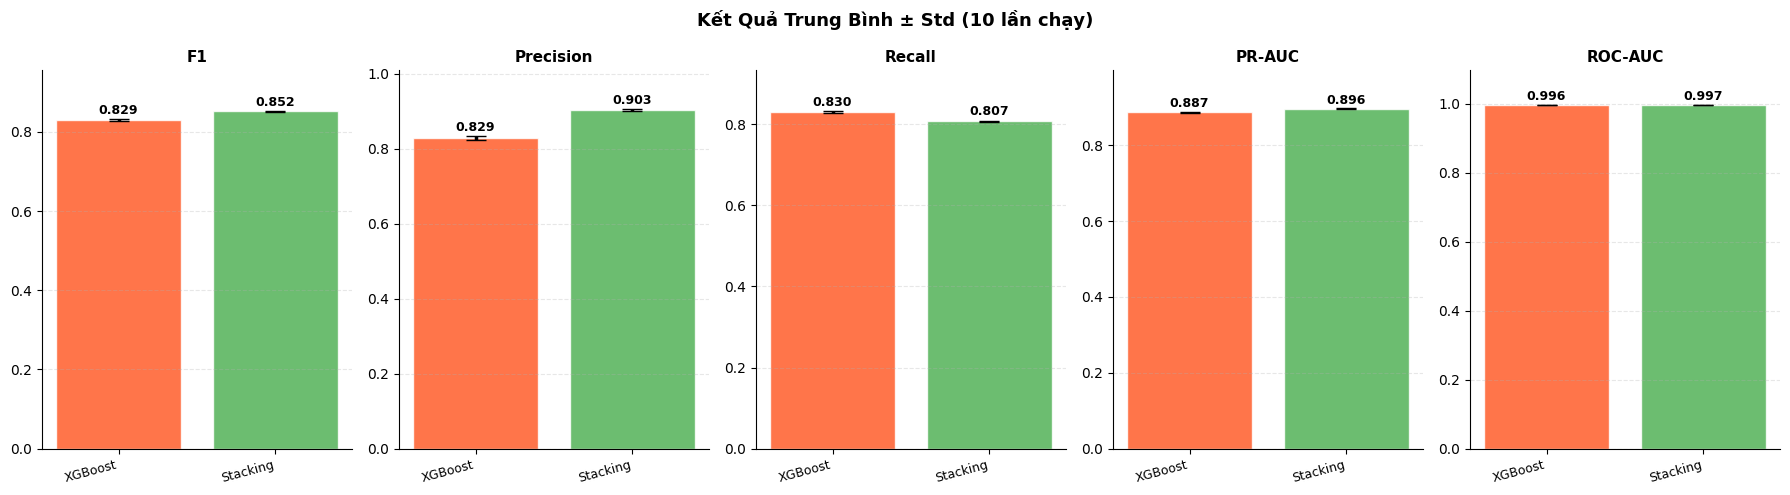


✅ Hoàn thành! Lưu kết quả lần cuối để vẽ biểu đồ chi tiết:
  y_proba_rf, y_pred_rf, y_proba_xgb, y_pred_xgb, final_proba, y_pred_stack


In [6]:
import matplotlib.pyplot as plt
model_names  = ['XGBoost', 'Stacking']
colors       = ['#FF5722', '#4CAF50']
plot_metrics = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(18, 5))
fig.suptitle(f'Kết Quả Trung Bình ± Std ({N_RUNS} lần chạy)',
             fontsize=13, fontweight='bold')
for ax, metric in zip(axes, plot_metrics):
    means = [summary[m]['mean'][metric] for m in model_names]
    stds  = [summary[m]['std'][metric]  for m in model_names]

    bars = ax.bar(model_names, means, yerr=stds, capsize=7,
                  color=colors, alpha=0.82, edgecolor='white',
                  error_kw={'elinewidth': 2.5, 'ecolor': 'black'})
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + std + 0.005,
                f'{mean:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ax.set_ylim(0, min(1.15, max(means) + max(stds) + 0.1))
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_title(metric.replace('_', '-'), fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig_mean_std_10runs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Hoàn thành! Lưu kết quả lần cuối để vẽ biểu đồ chi tiết:")
print("  y_proba_rf, y_pred_rf, y_proba_xgb, y_pred_xgb, final_proba, y_pred_stack")

In [7]:
# In kết quả từng lần chạy
print("\n" + "="*70)
print(f"  KẾT QUẢ TỪNG LẦN CHẠY")
print("="*70)

METRICS = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Accuracy']

for model_name in ['XGBoost', 'Stacking']:
    print(f"\n{'─'*70}")
    print(f"  {model_name}")
    print(f"{'─'*70}")
    print(f"  {'Run':<6}", end='')
    for m in METRICS:
        print(f"  {m:>10}", end='')
    print()
    print(f"  {'─'*65}")

    for i, run in enumerate(results[model_name]):
        print(f"  Run {i+1:<3}", end='')
        for m in METRICS:
            print(f"  {run[m]:>10.4f}", end='')
        print()

    # In mean và std ở cuối
    df_runs = pd.DataFrame(results[model_name])
    print(f"  {'─'*65}")
    print(f"  {'Mean':<6}", end='')
    for m in METRICS:
        print(f"  {df_runs[m].mean():>10.4f}", end='')
    print()
    print(f"  {'Std':<6}", end='')
    for m in METRICS:
        print(f"  {df_runs[m].std():>10.4f}", end='')
    print()


  KẾT QUẢ TỪNG LẦN CHẠY

──────────────────────────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────────────────────────
  Run             F1   Precision      Recall      PR_AUC     ROC_AUC    Accuracy
  ─────────────────────────────────────────────────────────────────
  Run 1        0.8276      0.8262      0.8289      0.8877      0.9963      0.9987
  Run 2        0.8246      0.8218      0.8275      0.8875      0.9962      0.9986
  Run 3        0.8290      0.8276      0.8303      0.8857      0.9961      0.9987
  Run 4        0.8296      0.8285      0.8308      0.8862      0.9961      0.9987
  Run 5        0.8345      0.8382      0.8308      0.8865      0.9961      0.9987
  Run 6        0.8308      0.8272      0.8345      0.8900      0.9959      0.9987
  Run 7        0.8260      0.8241      0.8280      0.8869      0.9963      0.9987
  Run 8        0.8325      0.8380      0.8270      0.8868      0.9961      0.9987
  Run 9        0.

## 3. XGBoost -- Danh gia voi feature moi

In [3]:

# ─────────────────────────────────────────────────────
# XGBOOST - Feature set moi
# ─────────────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train_bal, y_train_bal)

y_proba = xgb_model.predict_proba(X_test_sc)[:, 1]
y_pred  = (y_proba > 0.3).astype(int)

roc = roc_auc_score(y_test, y_proba)
pr  = average_precision_score(y_test, y_proba)

print("=== XGBoost ===")
print(f"ROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pr:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


NameError: name 'X_train_bal' is not defined

## 4. Feature Importance -- Feature moi dong gop bao nhieu?

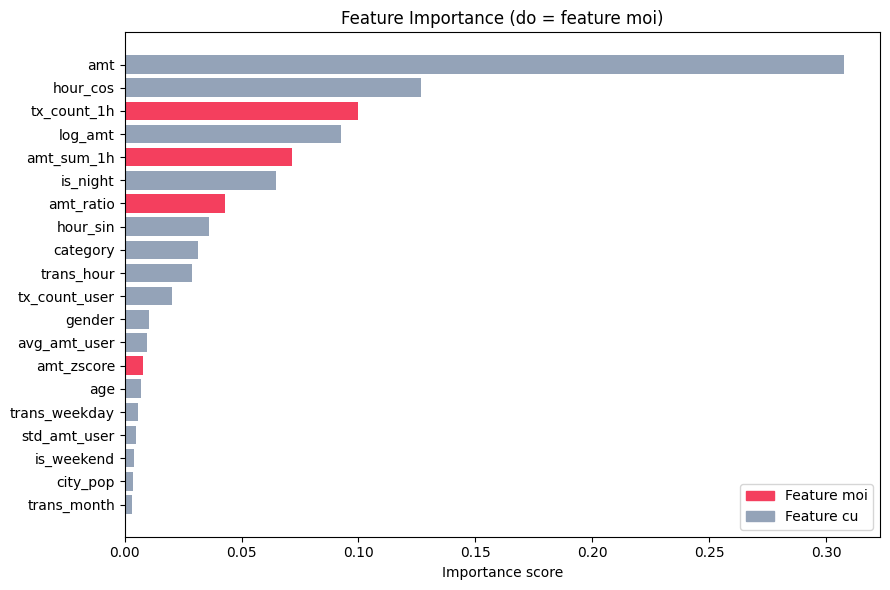


Top features moi:
  tx_count_1h                importance=0.0999  (rank #3/33)
  amt_sum_1h                 importance=0.0715  (rank #5/33)
  amt_zscore                 importance=0.0077  (rank #14/33)
  amt_ratio                  importance=0.0429  (rank #7/33)
  dist_from_prev             importance=0.0014  (rank #32/33)
  log_dist_from_prev         importance=0.0014  (rank #31/33)


In [5]:

# ─────────────────────────────────────────────────────
# FEATURE IMPORTANCE - Feature moi dong gop bao nhieu?
# ─────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

NEW_FEATURES = ['tx_count_1h', 'amt_sum_1h', 'amt_zscore', 'amt_ratio',
                'dist_from_prev', 'log_dist_from_prev']

importance = pd.Series(xgb_model.feature_importances_, index=feature_names)
top20 = importance.sort_values(ascending=True).tail(20)

colors = ['#f43f5e' if f in NEW_FEATURES else '#94a3b8' for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.index, top20.values, color=colors)
ax.set_title("Feature Importance (do = feature moi)")
ax.set_xlabel("Importance score")

legend = [mpatches.Patch(color='#f43f5e', label='Feature moi'),
          mpatches.Patch(color='#94a3b8', label='Feature cu')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

print("\nTop features moi:")
for f in NEW_FEATURES:
    if f in importance.index:
        rank = int(importance.rank(ascending=False)[f])
        print(f"  {f:25s}  importance={importance[f]:.4f}  (rank #{rank}/{len(importance)})")


## 5. Stacking XGBoost + LightGBM -- Feature moi

In [6]:

# ─────────────────────────────────────────────────────
# STACKING XGBoost + LightGBM - Feature set moi
# ─────────────────────────────────────────────────────
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgblib

xgb_params = dict(n_estimators=300, max_depth=8, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.7,
                  random_state=42, eval_metric='auc', n_jobs=-1)

lgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=8,
                  num_leaves=63, subsample=0.8, colsample_bytree=0.7,
                  random_state=42, n_jobs=-1, verbose=-1)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
meta_train = np.zeros((X_train_bal.shape[0], 2))
meta_test  = np.zeros((X_test_sc.shape[0], 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_bal, y_train_bal)):
    print(f"Fold {fold+1}/3 ...")
    X_tr, X_val = X_train_bal[train_idx], X_train_bal[val_idx]
    y_tr, y_val = y_train_bal[train_idx], y_train_bal[val_idx]

    xgb_f = XGBClassifier(**xgb_params)
    lgb_f = LGBMClassifier(**lgb_params)

    xgb_f.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    lgb_f.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgblib.early_stopping(50, verbose=False),
                         lgblib.log_evaluation(0)])

    meta_train[val_idx, 0] = xgb_f.predict_proba(X_val)[:, 1]
    meta_train[val_idx, 1] = lgb_f.predict_proba(X_val)[:, 1]
    meta_test[:, 0] += xgb_f.predict_proba(X_test_sc)[:, 1] / 3
    meta_test[:, 1] += lgb_f.predict_proba(X_test_sc)[:, 1] / 3

# Meta model: LogisticRegression (don gian, du voi 2 input features)
meta_model = LogisticRegression(C=1.0, max_iter=500, random_state=42)
meta_model.fit(meta_train, y_train_bal)

final_proba  = meta_model.predict_proba(meta_test)[:, 1]
roc = roc_auc_score(y_test, final_proba)
pr  = average_precision_score(y_test, final_proba)

print(f"\n=== Stacking Results ===")
print(f"ROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pr:.4f}")
print()
y_pred_stack = (final_proba > 0.3).astype(int)
print(classification_report(y_test, y_pred_stack, target_names=['Normal', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))


Fold 1/3 ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2/3 ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3/3 ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Stacking Results ===
ROC-AUC : 0.9967
PR-AUC  : 0.8969

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    553574
       Fraud       0.90      0.81      0.85      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.90      0.93    555719
weighted avg       1.00      1.00      1.00    555719

Confusion Matrix:
[[553389    185]
 [   417   1728]]


## 6. Lưu Model & Artifacts (Phiên bản đã sửa lỗi scaler)

In [ ]:

# ─────────────────────────────────────────────────────────────────
# LUU MODEL & ARTIFACTS (PHIEN BAN DUNG)
# Chay cell nay SAU KHI da chay xong toan bo pipeline phia tren
# ─────────────────────────────────────────────────────────────────
import joblib, os, json
import numpy as np
from datetime import datetime

SAVE_DIR = './models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── QUAN TRONG: Kiem tra cac bien can thiet ton tai ──────────────
required_vars = {
    'X_train_bal': 'numpy array sau SMOTE (CHUA scale)',
    'y_train_bal': 'labels sau SMOTE',
    'X_test_sc'  : 'numpy array sau scale',
    'y_test'     : 'test labels',
    'scaler'     : 'StandardScaler da fit_transform tren X_train_bal',
    'encoder'    : 'OrdinalEncoder da fit tren train set thuc',
    'feature_names': 'list ten features',
    'user_stats' : 'DataFrame thong ke theo cc_num',
    'xgb_f'      : 'XGBoost model (tu vong lap stacking)',
    'lgb_f'      : 'LightGBM model (tu vong lap stacking)',
    'meta_model' : 'LogisticRegression meta model',
    'roc'        : 'ROC-AUC score',
    'pr'         : 'PR-AUC score',
}

print("Kiem tra bien truoc khi luu:")
all_ok = True
for var, desc in required_vars.items():
    exists = var in dir() or var in locals() or var in globals()
    # Thu eval
    try:
        eval(var)
        print(f"  [OK] {var:20s} <- {desc}")
    except NameError:
        print(f"  [MISSING] {var:20s} <- {desc}  <-- CHUA CO, CHAY CELL TRUOC")
        all_ok = False

if not all_ok:
    raise RuntimeError("Mot so bien chua ton tai. Hay chay lai cac cell phia tren truoc.")

# ── VERIFY SCALER DUNG ────────────────────────────────────────────
# Scaler phai duoc fit tren X_train_bal (data GOC, CHUA scale)
# Neu mean~0 va std~1 thi scaler da fit sai tren data da scale roi!
if hasattr(scaler, 'mean_'):
    mean_amt = scaler.mean_[0]  # feature dau tien la 'amt'
    print(f"\nKiem tra scaler:")
    print(f"  mean cua 'amt' = {mean_amt:.4f}")
    if abs(mean_amt) < 1.0:
        print("  CANH BAO: mean~0 => scaler co the da fit tren data da scale!")
        print("  => Hay dam bao scaler.fit_transform(X_train_bal) voi X_train_bal la data GOC")
        print("  => KHONG phai fit tren X_train_sc (da scale roi)")
    else:
        print(f"  OK: mean = {mean_amt:.2f} (co ve la data goc)")

# ── LUU CAC ARTIFACTS ─────────────────────────────────────────────
print("\nBat dau luu...")

# 1. Base models tu vong lap stacking
joblib.dump(xgb_f,       f'{SAVE_DIR}/xgb_base.pkl')
print("[OK] xgb_base.pkl")

joblib.dump(lgb_f,       f'{SAVE_DIR}/lgb_base.pkl')
print("[OK] lgb_base.pkl")

# 2. Meta model
joblib.dump(meta_model,  f'{SAVE_DIR}/meta_model.pkl')
print("[OK] meta_model.pkl")

# 3. Scaler - PHAI la scaler da fit tren X_train_bal (data goc, chua scale)
#    KHONG luu scaler da fit tren X_train_sc
joblib.dump(scaler,      f'{SAVE_DIR}/scaler.pkl')
print("[OK] scaler.pkl")

# 4. Feature names
joblib.dump(feature_names, f'{SAVE_DIR}/feature_names.pkl')
print(f"[OK] feature_names.pkl ({len(feature_names)} features)")

# 5. Encoder - PHAI la encoder da fit tren train set THUC (khong phai mock)
#    Encoder nay phai co categories tu dataset thuc su
joblib.dump(encoder,     f'{SAVE_DIR}/encoder.pkl')
n_cats = sum(len(c) for c in encoder.categories_)
print(f"[OK] encoder.pkl ({n_cats} categories tong cong)")

# 6. user_stats
user_stats.to_csv(f'{SAVE_DIR}/user_stats.csv', index=False)
print("[OK] user_stats.csv")

# 7. Metadata
metadata = {
    "trained_at"    : datetime.now().isoformat(),
    "threshold"     : 0.3,
    "n_features"    : len(feature_names),
    "feature_names" : feature_names,
    "roc_auc"       : round(float(roc), 4),
    "pr_auc"        : round(float(pr),  4),
    "stacking"      : {"level1": ["XGBoost","LightGBM"], "level2": "LogisticRegression"},
    "smote_ratio"   : 0.2,
    "scaler_mean_amt": float(scaler.mean_[0]),
    "scaler_std_amt" : float(scaler.scale_[0]),
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print("[OK] metadata.json")

# ── VERIFY SAU KHI LUU ───────────────────────────────────────────
print("\n=== VERIFY ARTIFACTS DA LUU ===")
for fname in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}')
    print(f"  {fname:30s}  {size/1024:>8.1f} KB")

# Verify scaler mean hop ly
loaded_scaler = joblib.load(f'{SAVE_DIR}/scaler.pkl')
loaded_enc    = joblib.load(f'{SAVE_DIR}/encoder.pkl')
print(f"\nScaler mean[amt] = {loaded_scaler.mean_[0]:.4f}")
print(f"Encoder categories[0] sample: {list(loaded_enc.categories_[0][:5])}")

n_real_cats = len(loaded_enc.categories_[0])
if n_real_cats <= 3:
    print("CANH BAO: Encoder chi co <= 3 categories => co the la mock encoder!")
    print("=> Hay dam bao dung encoder da fit tren train set thuc")
else:
    print(f"OK: Encoder co {n_real_cats} categories cho col 0 (co ve thuc)")

print(f"\n[DONE] Luu xong! Copy thu muc '{SAVE_DIR}/' vao fraud_demo/models_store/")


In [8]:
# Luu XGBoost bang native JSON (khong bi version conflict)
# xgb_f.save_model('./models/xgb_base.json')

# # Luu LightGBM bang native text
# lgb_f.booster_.save_model('./models/lgb_base.txt')

## 7. Load lại & Verify (kiểm tra model hoạt động đúng)

In [9]:

# ─────────────────────────────────────────────────────────────────
# LOAD LAI & PREDICT THU DE KIEM TRA
# ─────────────────────────────────────────────────────────────────
import joblib, json
import numpy as np
import pandas as pd

SAVE_DIR = './models'

xgb_ld   = joblib.load(f'{SAVE_DIR}/xgb_base.pkl')
lgb_ld   = joblib.load(f'{SAVE_DIR}/lgb_base.pkl')
meta_ld  = joblib.load(f'{SAVE_DIR}/meta_model.pkl')
scaler_ld= joblib.load(f'{SAVE_DIR}/scaler.pkl')
feats_ld = joblib.load(f'{SAVE_DIR}/feature_names.pkl')

with open(f'{SAVE_DIR}/metadata.json') as f:
    meta_info = json.load(f)

THRESHOLD = meta_info['threshold']

# Lay 10 sample tu test set de kiem tra
sample_X = X_test_sc[:10]  # da scale san

p_xgb  = xgb_ld.predict_proba(sample_X)[:, 1]
p_lgb  = lgb_ld.predict_proba(sample_X)[:, 1]
meta_X = np.column_stack([p_xgb, p_lgb])
p_meta = meta_ld.predict_proba(meta_X)[:, 1]

print("=== KIEM TRA 10 SAMPLE TU TEST SET ===")
print(f"Threshold: {THRESHOLD}")
print(f"\n  {'#':>3}  {'Actual':>8}  {'XGB':>7}  {'LGB':>7}  {'Stack':>7}  {'Predict'}")
print("  " + "-"*55)

y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
n_correct = 0
for i in range(10):
    actual  = int(y_test_arr[i])
    pred    = "FRAUD" if p_meta[i] >= THRESHOLD else "legit"
    correct = ((actual==1) == (p_meta[i]>=THRESHOLD))
    if correct: n_correct += 1
    mark = "OK" if correct else "WRONG"
    print(f"  {i:>3}  {'FRAUD' if actual==1 else 'legit':>8}  "
          f"{p_xgb[i]:>6.1%}  {p_lgb[i]:>6.1%}  {p_meta[i]:>6.1%}  {pred:>7}  {mark}")

print(f"\nDung {n_correct}/10")

# Kiem tra co bi predict het FRAUD khong
if all(p >= THRESHOLD for p in p_meta):
    print("\nCANH BAO: Tat ca 10 sample deu FRAUD => model co van de!")
elif all(p < THRESHOLD for p in p_meta):
    print("\nCANH BAO: Tat ca 10 sample deu legit => threshold qua cao?")
else:
    print("\nOK: Model phan biet duoc 2 class!")


=== KIEM TRA 10 SAMPLE TU TEST SET ===
Threshold: 0.3

    #    Actual      XGB      LGB    Stack  Predict
  -------------------------------------------------------
    0     legit    0.0%    0.0%    0.1%    legit  OK
    1     legit    0.0%    0.0%    0.1%    legit  OK
    2     legit    0.0%    0.0%    0.1%    legit  OK
    3     legit    0.1%    0.0%    0.1%    legit  OK
    4     legit    0.0%    0.0%    0.1%    legit  OK
    5     legit    0.0%    0.0%    0.1%    legit  OK
    6     legit    0.0%    0.0%    0.1%    legit  OK
    7     legit    0.0%    0.0%    0.1%    legit  OK
    8     legit    0.1%    0.1%    0.1%    legit  OK
    9     legit    0.0%    0.0%    0.1%    legit  OK

Dung 10/10

CANH BAO: Tat ca 10 sample deu legit => threshold qua cao?


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
